C:\Users\adegi\AppData\Local\Temp\ipykernel_13412\484480927.py:21: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['MatchDate'] = pd.to_datetime(df['MatchDate'], errors='coerce')
C:\Users\adegi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adegi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


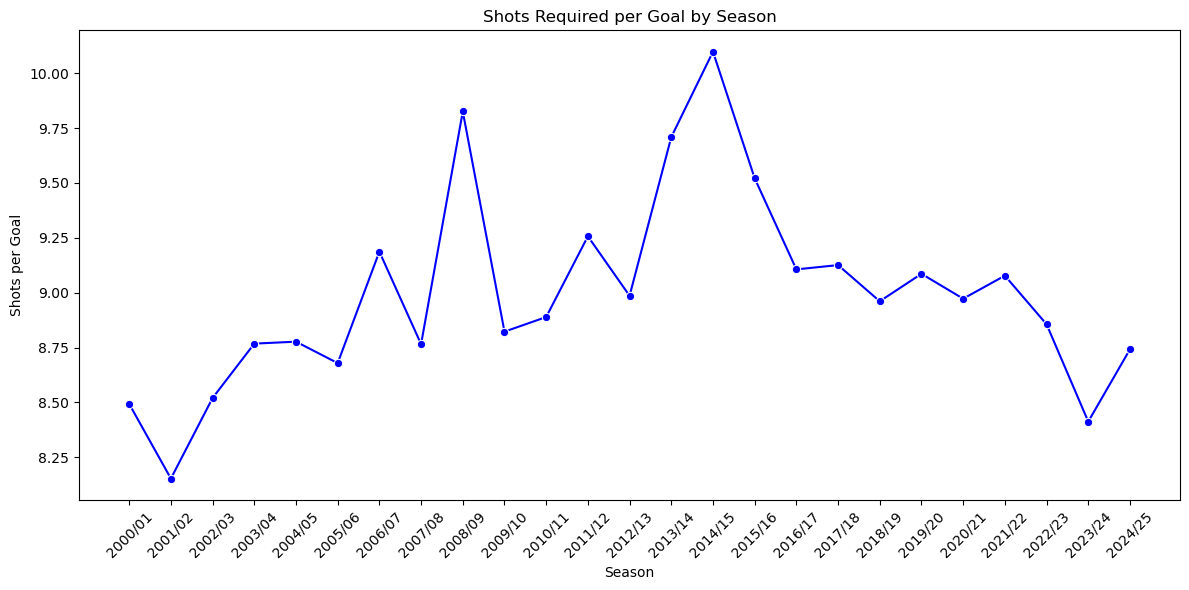

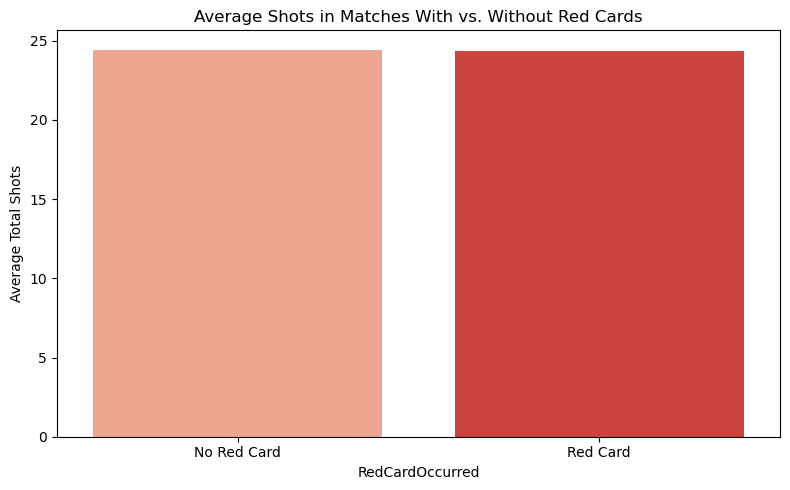

In [1]:
# 📊 English Premier League Analytics
# Analysis of shots vs. goals and red card impact across seasons

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('C:/Users/adegi/OneDrive/Desktop/Aren Work/Football Analytics/data/epl_final.csv')

# Preview the data
df.head()

# Select relevant columns
df = df[['Season', 'MatchDate', 'HomeTeam', 'AwayTeam',
         'FullTimeHomeGoals', 'FullTimeAwayGoals',
         'HomeShots', 'AwayShots',
         'HomeRedCards', 'AwayRedCards']]

# Convert MatchDate to datetime
df['MatchDate'] = pd.to_datetime(df['MatchDate'], errors='coerce')

# Create total goals and total shots columns
df['TotalGoals'] = df['FullTimeHomeGoals'] + df['FullTimeAwayGoals']
df['TotalShots'] = df['HomeShots'] + df['AwayShots']
df['TotalRedCards'] = df['HomeRedCards'] + df['AwayRedCards']

# Group by season to analyse shots per goal
season_summary = df.groupby('Season').agg({
    'TotalGoals': 'sum',
    'TotalShots': 'sum',
    'TotalRedCards': 'sum'
}).reset_index()

season_summary['ShotsPerGoal'] = season_summary['TotalShots'] / season_summary['TotalGoals']

# 📈 Visualise Shots per Goal over Seasons
plt.figure(figsize=(12,6))
sns.lineplot(data=season_summary, x='Season', y='ShotsPerGoal', marker='o', color='blue')
plt.xticks(rotation=45)
plt.title('Shots Required per Goal by Season')
plt.ylabel('Shots per Goal')
plt.xlabel('Season')
plt.tight_layout()
plt.savefig('C:/Users/adegi/OneDrive/Desktop/Aren Work/Football Analytics/visuals/shots_per_goal_by_season.png')
plt.show()

# 🔴 Red Card Impact: Average Shots in Matches with vs. without Red Cards
df['RedCardOccurred'] = df['TotalRedCards'] > 0

redcard_impact = df.groupby('RedCardOccurred').agg({
    'TotalShots': 'mean',
    'TotalGoals': 'mean'
}).reset_index()

# 📊 Bar Chart: Red Card Impact on Shots
plt.figure(figsize=(8,5))
sns.barplot(data=redcard_impact, x='RedCardOccurred', y='TotalShots', palette='Reds')
plt.xticks([0,1], ['No Red Card', 'Red Card'])
plt.title('Average Shots in Matches With vs. Without Red Cards')
plt.ylabel('Average Total Shots')
plt.tight_layout()
plt.savefig('C:/Users/adegi/OneDrive/Desktop/Aren Work/Football Analytics/visuals/red_card_shot_impact.png')
plt.show()


C:\Users\adegi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adegi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adegi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\adegi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

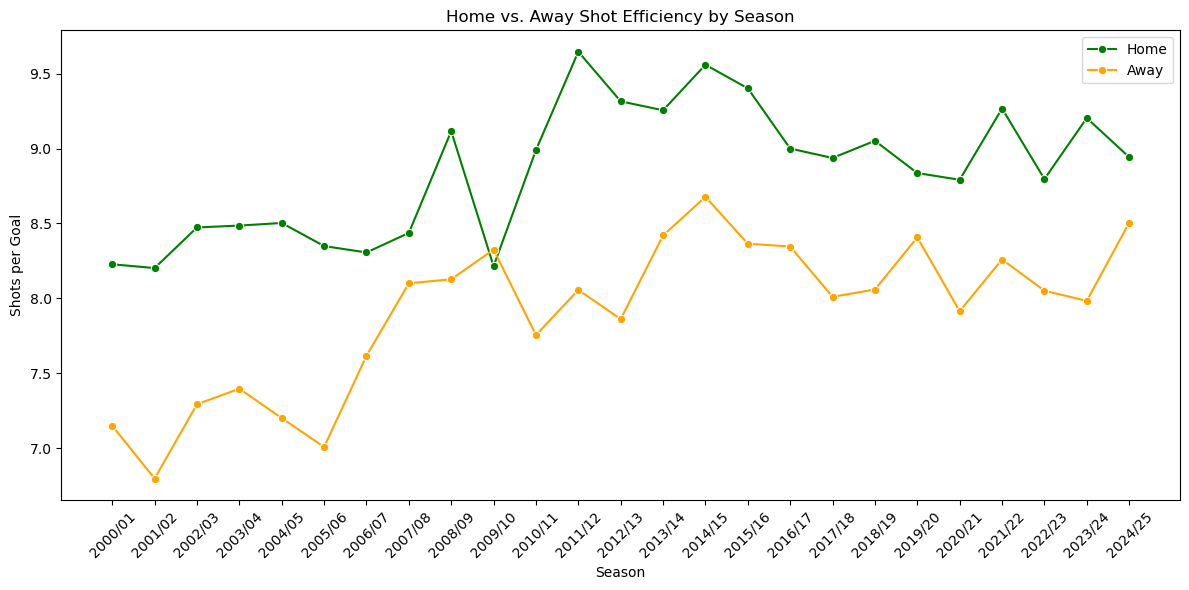

In [2]:
# 🏠 vs. 🛫 Home vs. Away Shot Efficiency

# Avoid division by zero by replacing 0 goals with NA
df['HomeShotsPerGoal'] = df['HomeShots'] / df['FullTimeHomeGoals'].replace(0, pd.NA)
df['AwayShotsPerGoal'] = df['AwayShots'] / df['FullTimeAwayGoals'].replace(0, pd.NA)

# Group by season and calculate average efficiency
efficiency_by_season = df.groupby('Season').agg({
    'HomeShotsPerGoal': 'mean',
    'AwayShotsPerGoal': 'mean'
}).reset_index()

# 📈 Line Plot: Home vs. Away Shot Efficiency
plt.figure(figsize=(12,6))
sns.lineplot(data=efficiency_by_season, x='Season', y='HomeShotsPerGoal', label='Home', marker='o', color='green')
sns.lineplot(data=efficiency_by_season, x='Season', y='AwayShotsPerGoal', label='Away', marker='o', color='orange')
plt.xticks(rotation=45)
plt.title('Home vs. Away Shot Efficiency by Season')
plt.ylabel('Shots per Goal')
plt.xlabel('Season')
plt.legend()
plt.tight_layout()
plt.savefig('C:/Users/adegi/OneDrive/Desktop/Aren Work/Football Analytics/visuals/home_vs_away_shot_efficiency.png')
plt.show()

In [18]:
# 🏠 vs. 🛫 Home vs. Away Shot Efficiency Table with Difference (Rounded to 1 Decimal Place)

# Avoid division by zero by replacing 0 goals with NaN
df['HomeShotsPerGoal'] = df['HomeShots'] / df['FullTimeHomeGoals'].replace(0, pd.NA)
df['AwayShotsPerGoal'] = df['AwayShots'] / df['FullTimeAwayGoals'].replace(0, pd.NA)

# Group by season and calculate average efficiency
efficiency_by_season = df.groupby('Season').agg({
    'HomeShotsPerGoal': 'mean',
    'AwayShotsPerGoal': 'mean'
}).reset_index()

# Calculate the difference
efficiency_by_season['EfficiencyGap'] = efficiency_by_season['HomeShotsPerGoal'] - efficiency_by_season['AwayShotsPerGoal']

# Round to 1 decimal place
efficiency_table = efficiency_by_season[['Season', 'HomeShotsPerGoal', 'AwayShotsPerGoal', 'EfficiencyGap']].round(1)

# Format float columns to show exactly 1 decimal place
efficiency_table['HomeShotsPerGoal'] = efficiency_table['HomeShotsPerGoal'].map('{:.1f}'.format)
efficiency_table['AwayShotsPerGoal'] = efficiency_table['AwayShotsPerGoal'].map('{:.1f}'.format)
efficiency_table['EfficiencyGap'] = efficiency_table['EfficiencyGap'].map('{:.1f}'.format)

# 🖨️ Print the formatted table
print(efficiency_table.to_string(index=False))

 Season HomeShotsPerGoal AwayShotsPerGoal EfficiencyGap
2000/01              8.2              7.1           1.1
2001/02              8.2              6.8           1.4
2002/03              8.5              7.3           1.2
2003/04              8.5              7.4           1.1
2004/05              8.5              7.2           1.3
2005/06              8.3              7.0           1.3
2006/07              8.3              7.6           0.7
2007/08              8.4              8.1           0.3
2008/09              9.1              8.1           1.0
2009/10              8.2              8.3          -0.1
2010/11              9.0              7.8           1.2
2011/12              9.6              8.1           1.6
2012/13              9.3              7.9           1.5
2013/14              9.3              8.4           0.8
2014/15              9.6              8.7           0.9
2015/16              9.4              8.4           1.0
2016/17              9.0              8.3       

In [14]:
# ⚽ Total Goals and Proportions by Season (Clean Integer Percentages)

# Ensure numeric types
df['FullTimeHomeGoals'] = pd.to_numeric(df['FullTimeHomeGoals'], errors='coerce')
df['FullTimeAwayGoals'] = pd.to_numeric(df['FullTimeAwayGoals'], errors='coerce')

# Create total goals column
df['FullTimeTotalGoals'] = df['FullTimeHomeGoals'] + df['FullTimeAwayGoals']

# Group by season and sum goals
goals_by_season = df.groupby('Season').agg({
    'FullTimeHomeGoals': 'sum',
    'FullTimeAwayGoals': 'sum',
    'FullTimeTotalGoals': 'sum'
}).reset_index()

# Calculate percentages
goals_by_season['FullTimeHomeGoalsPercent'] = ((goals_by_season['FullTimeHomeGoals'] / goals_by_season['FullTimeTotalGoals']) * 100).astype(int)
goals_by_season['FullTimeAwayGoalsPercent'] = ((goals_by_season['FullTimeAwayGoals'] / goals_by_season['FullTimeTotalGoals']) * 100).astype(int)

# Round goal totals and convert to integers
goals_by_season = goals_by_season.round({
    'FullTimeHomeGoals': 0,
    'FullTimeAwayGoals': 0,
    'FullTimeTotalGoals': 0
}).astype({
    'FullTimeHomeGoals': int,
    'FullTimeAwayGoals': int,
    'FullTimeTotalGoals': int
})

# 🖨️ Print the final goals table
print(goals_by_season.to_string(index=False))


 Season  FullTimeHomeGoals  FullTimeAwayGoals  FullTimeTotalGoals  FullTimeHomeGoalsPercent  FullTimeAwayGoalsPercent
2000/01                587                405                 992                        59                        40
2001/02                557                444                1001                        55                        44
2002/03                570                430                1000                        56                        43
2003/04                500                383                 883                        56                        43
2004/05                492                359                 851                        57                        42
2005/06                555                389                 944                        58                        41
2006/07                552                379                 931                        59                        40
2007/08                581                421           